根据每局比赛的过程值预测比赛结果

In [1]:
%pip install shap
import shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm
from tqdm.auto import tqdm
tqdm.pandas()
import os
import math
import psutil
import gc
import chess
import chess.engine
import chess.svg
from IPython.display import display, HTML
import subprocess
import time
from pathlib import Path
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import matplotlib.patches as patches
import sqlite3
from matplotlib.patches import ConnectionPatch, Rectangle
from functools import reduce

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

df_moves = pd.read_parquet(r'..\df_moves6.parquet')

In [3]:
df_moves.columns

Index(['uid', 'Move_Idx', 'Player', 'Color', 'E', 'E1', 'E2', 'E3', 'E4', 'E5',
       'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO', 'ELO_Group',
       'Is_Forced', 'Is_Optimal', 'Remain_Time', 'Time_Group', 'Move_Time',
       'Game_Length', 'Progress', 'Relative_Stage(temp)', 'Is_check',
       'Is_checkmate', 'Result', 'P_model', 'S', 'P_model(Global=10.0cp)',
       'S(Global=10.0cp)', 'P_model(Global=50.0cp)', 'S(Global=50.0cp)',
       'P_model(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_model(Global=150.0cp)', 'S(Global=150.0cp)', 'D', 'Cog_Speed'],
      dtype='object')

In [4]:
df_moves = df_moves[['uid', 'Move_Idx', 'Player', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO',
       'Is_Forced', 'Is_Optimal', 'Remain_Time', 'Move_Time',
       'Game_Length', 'Progress', 'Is_check', 'Is_checkmate', 'Result', 'D', 'Cog_Speed']]
df_moves.head()

,uid,Move_Idx,Player,Is_Error,Is_Blunder,Δi,Δ,ELO,Is_Forced,Is_Optimal,Remain_Time,Move_Time,Game_Length,Progress,Is_check,Is_checkmate,Result,D,Cog_Speed
0,34,1,Dennis Wagner,0,0,3.0,6.0,2802.0,0,1,179.800003,1.2,63,0.015873,0,0,win,0.833333,0.69
1,34,2,Petar Ratkovic,0,0,3.0,4.0,2463.0,0,1,177.800003,3.2,63,0.031746,0,0,lose,0.882353,0.28
2,34,3,Dennis Wagner,0,0,6.0,7.0,2802.0,0,1,178.500000,2.3,63,0.047619,0,0,win,0.810811,0.35
3,34,4,Petar Ratkovic,0,0,14.0,38.0,2463.0,0,0,178.699997,0.1,63,0.063492,0,0,lose,0.441176,NaN
4,34,5,Dennis Wagner,0,0,12.0,15.0,2802.0,0,0,179.199997,0.3,63,0.079365,0,0,win,0.666667,NaN


In [5]:
df_moves['Result'].values

['win', 'lose', 'win', 'lose', 'win', ..., 'draw', 'draw', 'draw', 'draw', 'draw']
Length: 88912034
Categories (3, object): ['draw', 'lose', 'win']

In [6]:
for col in ['uid', 'Player', 'node_score']:
    if col in df_moves.columns:
        if df_moves[col].dtype == 'int64':
            df_moves[col] = pd.to_numeric(df_moves[col], downcast='integer')
        if df_moves[col].dtype == 'float64':
            df_moves[col] = pd.to_numeric(df_moves[col], downcast='float')

In [ ]:
# 提取微型数据框并预过滤
mask = df_moves['Progress'] >= 0.5
slim_df = df_moves.loc[mask, ['uid', 'Player', 'Progress', 'Move_Idx', 'Remain_Time']]

# 算残差
time_baseline = df_moves.groupby('Move_Idx')['Remain_Time'].mean().astype('float32')
slim_df['Expected_Remain'] = slim_df['Move_Idx'].map(time_baseline)
slim_df['Time_Residual'] = slim_df['Remain_Time'] - slim_df['Expected_Remain']

progress_stones = [0.6, 0.7, 0.8, 0.9]
tm_scores_list = []

# 迭代计算每个节点的得分，存入列表
for p in progress_stones:
    # 将绝对值距离算成一列 'dist'
    slim_df['dist'] = (slim_df['Progress'] - p).abs()
    
    # 按照 'dist' 列去找最小值对应的索引
    idx = slim_df.groupby(['uid', 'Player'], observed=True)['dist'].idxmin()
    target_rows = slim_df.loc[idx]
    # 计算得分，统一列名 node_score
    target_rows['node_score'] = (target_rows['Time_Residual'] / 180.0) * target_rows['Progress']
    tm_scores_list.append(target_rows[['uid', 'Player', 'node_score']])
# 纵向合并代替横向合并
all_nodes_df = pd.concat(tm_scores_list, ignore_index=True)
# 聚合局级时间管理分
game_level_tm = all_nodes_df.groupby(['uid', 'Player'], observed=True)['node_score'].sum().reset_index()
game_level_tm.rename(columns={'node_score': 'Time_Management_Score'}, inplace=True)
game_level_tm['Time_Management_Score'] = game_level_tm['Time_Management_Score'].round(2)

del slim_df, time_baseline, tm_scores_list, all_nodes_df
gc.collect()
df_moves = df_moves.merge(game_level_tm, on=['uid', 'Player'], how='left')
del game_level_tm
gc.collect()

print("时间管理分计算完成！")

Step 3: 时间管理分计算完成！


In [8]:
df_moves.columns

Index(['uid', 'Move_Idx', 'Player', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO',
       'Is_Forced', 'Is_Optimal', 'Remain_Time', 'Move_Time', 'Game_Length',
       'Progress', 'Is_check', 'Is_checkmate', 'Result', 'D', 'Cog_Speed',
       'Time_Management_Score'],
      dtype='object')

In [ ]:
# result结果映射
result_map = {'win': 1, 'lose': -1, 'draw': 0}
df_moves['Target'] = df_moves['Result'].map(result_map).astype('float32')

# 将单步特征求平均 (mean)，局级特征取第一个值 (first)
game_features = df_moves.groupby(['uid', 'Player'], observed=True).agg({
    'Is_Optimal': 'mean',
    'Is_Error': 'mean', 
    'Is_Blunder': 'mean',
    'Δi': 'mean',          
    'D': 'mean',
    'Cog_Speed': 'mean',
    'Time_Management_Score': 'first', # 因为这一局里每步的这个分数都一样，取首个
    'ELO': 'first',
    'Target': 'first'
}).reset_index()

# 核心特征列表：把 'ELO' 加进来
features_to_diff = [
    'ELO',
    'Is_Optimal', 'Is_Error', 'Is_Blunder', 
    'Δi', 'D', 'Cog_Speed', 'Time_Management_Score'
]

# 对手信息表
opponent_cols = ['uid', 'Player'] + features_to_diff
opponent_info = game_features[opponent_cols].copy()

rename_dict = {'Player': 'Opponent'}
for col in features_to_diff:
    rename_dict[col] = f'Opp_{col}'
opponent_info.rename(columns=rename_dict, inplace=True)
game_features = game_features.merge(opponent_info, on='uid', how='inner')

# 过滤掉“自己对自己”的行
game_features = game_features[game_features['Player'] != game_features['Opponent']].copy()

# 批量计算 Diff 特征
for col in features_to_diff:
    game_features[f'{col}_Diff'] = game_features[col] - game_features[f'Opp_{col}']

cols_to_drop = [f'Opp_{col}' for col in features_to_diff]
game_features.drop(columns=cols_to_drop, inplace=True)
del opponent_info
gc.collect()
print("加入对抗 Diff 后的特征列：")
print(game_features.columns.tolist())

加入对抗 Diff 后的特征列：
['uid', 'Player', 'Is_Optimal', 'Is_Error', 'Is_Blunder', 'Δi', 'D', 'Cog_Speed', 'Time_Management_Score', 'ELO', 'Target', 'Opponent', 'ELO_Diff', 'Is_Optimal_Diff', 'Is_Error_Diff', 'Is_Blunder_Diff', 'Δi_Diff', 'D_Diff', 'Cog_Speed_Diff', 'Time_Management_Score_Diff']


In [10]:
game_features = game_features.drop(columns=['Opponent'])
game_features.head()

,uid,Player,Is_Optimal,Is_Error,Is_Blunder,Δi,D,Cog_Speed,Time_Management_Score,ELO,Target,ELO_Diff,Is_Optimal_Diff,Is_Error_Diff,Is_Blunder_Diff,Δi_Diff,D_Diff,Cog_Speed_Diff,Time_Management_Score_Diff
1,1,Daniel Barria,0.923077,0.000000,0.000000,2.000000,0.537795,0.347500,0.22,2637.0,1.0,460.0,0.076923,-0.153846,-0.153846,-36.307693,-0.113450,-0.186136,-0.02
2,1,Petra Kejzar,0.846154,0.153846,0.153846,38.307693,0.651245,0.533636,0.24,2177.0,-1.0,-460.0,-0.076923,0.153846,0.153846,36.307693,0.113450,0.186136,0.02
5,2,Jorge Carlos Antonio,0.461538,0.307692,0.230769,788.692322,0.458179,0.396667,-0.06,2195.0,-1.0,-444.0,-0.109890,0.236264,0.230769,768.620911,-0.061178,0.065417,-0.20
6,2,Nataliya Buksa,0.571429,0.071429,0.000000,20.071428,0.519357,0.331250,0.14,2639.0,1.0,444.0,0.109890,-0.236264,-0.230769,-768.620911,0.061178,-0.065417,0.20
9,3,Nikolaos Skiadopoulos,0.736842,0.105263,0.105263,63.578949,0.373199,0.229286,0.41,2049.0,-1.0,-558.0,0.236842,0.005263,0.055263,32.728951,-0.071206,-0.137714,0.11


In [11]:
game_features.columns

Index(['uid', 'Player', 'Is_Optimal', 'Is_Error', 'Is_Blunder', 'Δi', 'D',
       'Cog_Speed', 'Time_Management_Score', 'ELO', 'Target', 'ELO_Diff',
       'Is_Optimal_Diff', 'Is_Error_Diff', 'Is_Blunder_Diff', 'Δi_Diff',
       'D_Diff', 'Cog_Speed_Diff', 'Time_Management_Score_Diff'],
      dtype='object')

In [12]:
game_features.shape

(2014682, 19)

## 二分类


--- 仅使用 ELO 预测 ---
[LightGBM] [Info] Number of positive: 734019, number of negative: 734813
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001563 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 1468832, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499730 -> initscore=-0.001081
[LightGBM] [Info] Start training from score -0.001081
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's binary_logloss: 0.499656

【单局胜负预测结果】
准确率 (Accuracy): 0.7696
AUC Score: 0.8365


<Figure size 800x600 with 0 Axes>

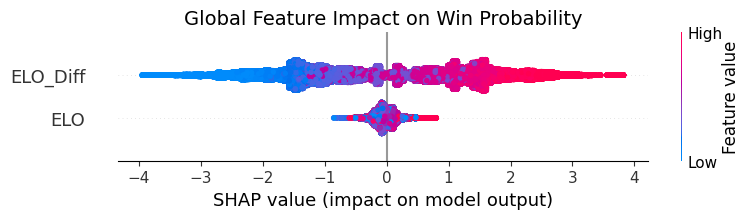

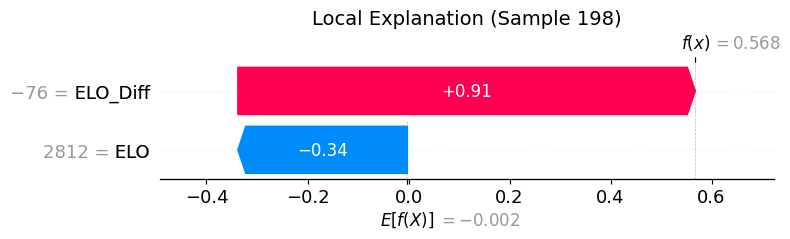


[提示] 当前特征集不包含 Cog_Speed_Diff，跳过该图。

[提示] 当前特征集不包含 Time_Management_Score_Diff，跳过该图。

--- 使用 ELO 和其他特征预测 ---
[LightGBM] [Info] Number of positive: 734019, number of negative: 734813
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002074 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 1468832, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499730 -> initscore=-0.001081
[LightGBM] [Info] Start training from score -0.001081
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's binary_logloss: 0.415989

【单局胜负预测结果】
准确率 (Accuracy): 0.8109
AUC Score: 0.8913


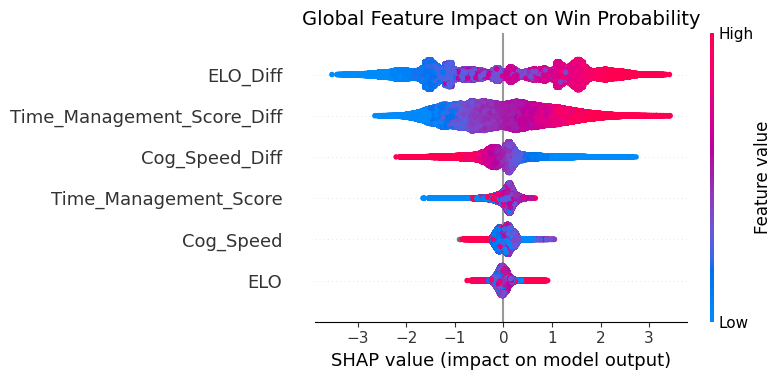

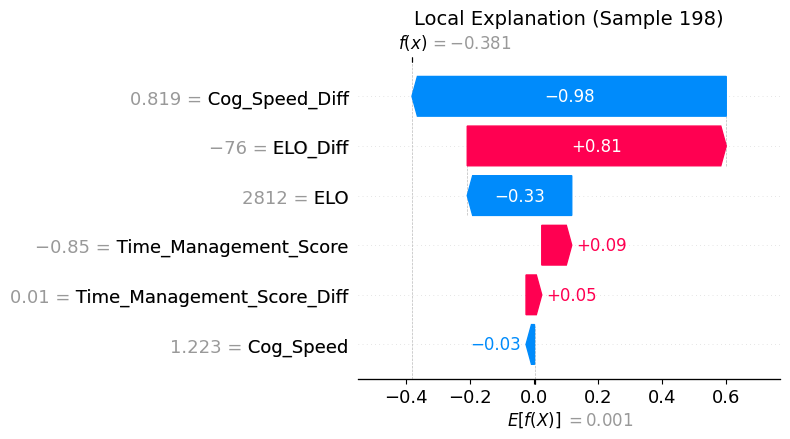

c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:190: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


<Figure size 800x600 with 0 Axes>

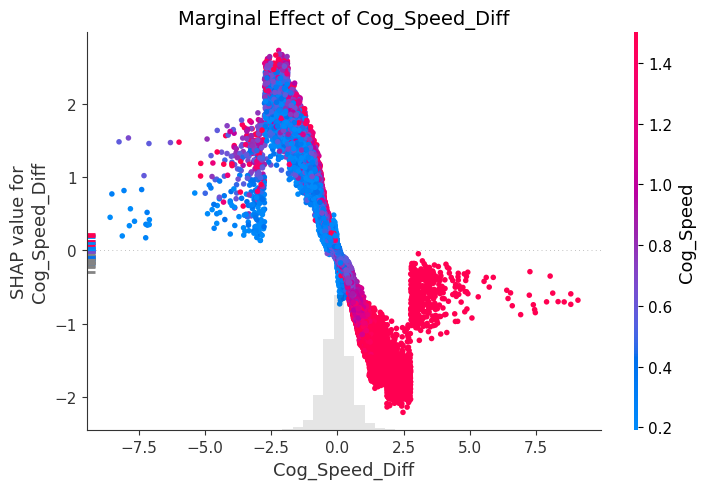

<Figure size 800x600 with 0 Axes>

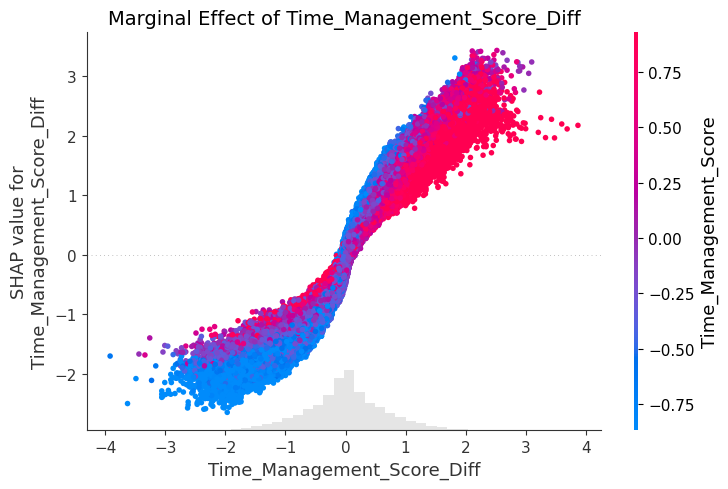

In [37]:
df_model = game_features.copy()
df_model = df_model[df_model['Target'] != 0].copy()
df_model['Target'] = df_model['Target'].apply(lambda x: 1 if x == 1 else 0)
default_features = ['ELO', 'ELO_Diff']  # 只使用 ELO 相关特征
additional_features = [ # 'Is_Error', 'Is_Blunder', 'Is_Error_Diff', 'Is_Blunder_Diff',
                        # 'Δi', 'D', 'Is_Optimal', 'Is_Optimal_Diff', 'Δi_Diff', 'D_Diff', 
                       'Cog_Speed', 'Time_Management_Score', 
                       'Cog_Speed_Diff', 'Time_Management_Score_Diff']  # 其他特征

def get_features(include_additional=True):
    if include_additional:
        return default_features + additional_features  # 包括ELO和其他特征
    else:
        return default_features  # 只包含ELO相关特征
def prepare_data(include_additional=True):
    features = get_features(include_additional)
    X = df_model[features]
    y = df_model['Target']
    return X, y

# 模型训练与评估
def train_and_evaluate(include_additional=True):
    X, y = prepare_data(include_additional)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # LightGBM
    clf = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], callbacks=[lgb.early_stopping(50)])
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
    print("\n【单局胜负预测结果】")
    print(f"准确率 (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
    print(f"AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
    
    return clf, X_test, y_test, y_pred, y_prob

# SHAP 分析
def shap_analysis(clf, X_test):
    explainer = shap.TreeExplainer(clf)
    shap_explanation = explainer(X_test) 

    if len(shap_explanation.shape) == 3:
        shap_explanation = shap_explanation[:, :, 1]

    # 图 1：全局蜂群图
    plt.figure(figsize=(10, 6))
    shap.plots.beeswarm(shap_explanation, max_display=15, show=False) 
    plt.title("Global Feature Impact on Win Probability", fontsize=14)
    plt.tight_layout()
    plt.show()

    # 图 2：单局微观剖析
    sample_idx = 198  
    plt.figure(figsize=(8, 6))
    shap.plots.waterfall(shap_explanation[sample_idx], max_display=10, show=False)
    plt.title(f"Local Explanation (Sample {sample_idx})", fontsize=14)
    plt.tight_layout()
    plt.show()

    # 图 3 & 4：特征依赖图 (增加健壮性检查)
    features_to_check = ["Cog_Speed_Diff", "Time_Management_Score_Diff"]
    
    # 定义对应特征倾向于关联的颜色特征（如果存在的话）
    color_map = {
        "Cog_Speed_Diff": "Cog_Speed",
        "Time_Management_Score_Diff": "Time_Management_Score"
    }

    for feature_to_plot in features_to_check:
        if feature_to_plot in X_test.columns:
            plt.figure(figsize=(8, 6))
            
            # 核心修复逻辑：检查颜色特征是否存在
            target_color_feature = color_map.get(feature_to_plot)
            if target_color_feature and target_color_feature in X_test.columns:
                # 如果指定的原始分数特征存在，则用它上色
                color_setting = shap_explanation[:, target_color_feature]
            else:
                # 如果不存在（比如你现在的情况），则设为 None
                # SHAP 会自动寻找最强的交互特征或者不使用颜色
                color_setting = None
            
            shap.plots.scatter(
                shap_explanation[:, feature_to_plot], 
                color=color_setting, 
                show=False
            )
            plt.title(f"Marginal Effect of {feature_to_plot}", fontsize=14)
            plt.tight_layout()
            plt.show()
        else:
            print(f"\n[提示] 当前特征集不包含 {feature_to_plot}，跳过该图。")

# 进行两种模型的训练与评估
print("\n--- 仅使用 ELO 预测 ---")
clf_elo, X_test_elo, y_test_elo, y_pred_elo, y_prob_elo = train_and_evaluate(include_additional=False)
shap_analysis(clf_elo, X_test_elo)

print("\n--- 使用 ELO 和其他特征预测 ---")
clf_all, X_test_all, y_test_all, y_pred_all, y_prob_all = train_and_evaluate(include_additional=True)
shap_analysis(clf_all, X_test_all)


实验：仅使用行为特征 (不给模型 ELO 信息)

>>> 当前训练模式: behavior | 特征数量: 1
[LightGBM] [Info] Number of positive: 734019, number of negative: 734813
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001189 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 1468832, number of used features: 1
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499730 -> initscore=-0.001081
[LightGBM] [Info] Start training from score -0.001081
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[103]	valid_0's binary_logloss: 0.571566
准确率 (Accuracy): 0.7029
AUC Score: 0.7724


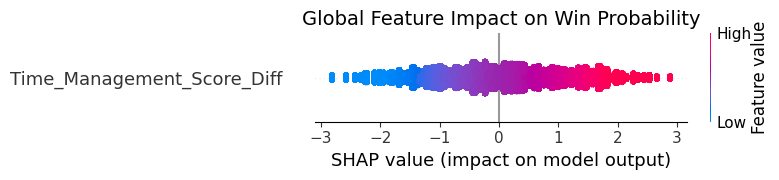

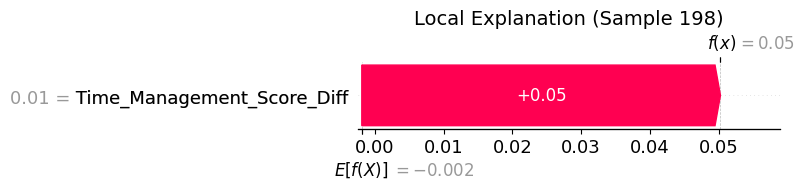


[提示] 当前特征集不包含 Cog_Speed_Diff，跳过该图。


<Figure size 800x600 with 0 Axes>

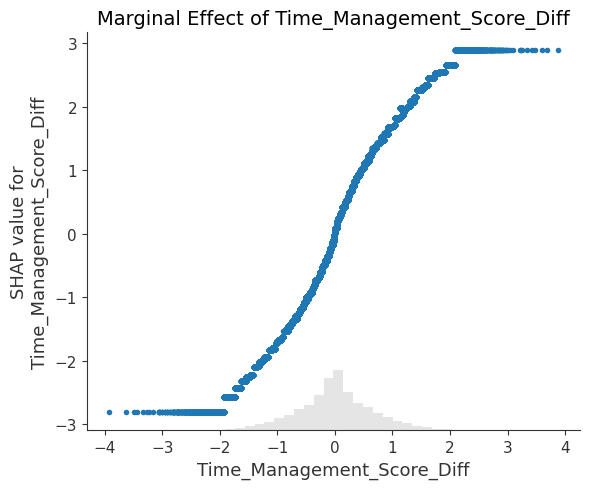

In [39]:
default_features = ['ELO', 'ELO_Diff']
# 定义的行为特征，可随时增删注释选择特征
behavioral_features = [
    # 'Cog_Speed', 
    # 'Time_Management_Score', 
    # 'Cog_Speed_Diff', 
    'Time_Management_Score_Diff',
    # 'D_Diff',    
    # 'Δi_Diff', 
]


def get_features(mode='all'):
    """
    mode: 
      'all'  ELO + 行为特征
      'elo'  仅使用 ELO 相关
      'behavior'  仅使用行为特征 (不含 ELO)
    """
    if mode == 'all':
        return default_features + behavioral_features
    elif mode == 'elo':
        return default_features
    elif mode == 'behavior':
        return behavioral_features
    else:
        raise ValueError("Mode must be 'all', 'elo', or 'behavior'")

def prepare_data(mode='all'):
    features = get_features(mode)
    X = df_model[features]
    y = df_model['Target']
    return X, y

# 模型训练与评估 (增加一个 mode 参数)
def train_and_evaluate(mode='all'):
    X, y = prepare_data(mode)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"\n>>> 当前训练模式: {mode} | 特征数量: {len(X.columns)}")
    
    clf = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], callbacks=[lgb.early_stopping(50)])
    
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
    
    print(f"准确率 (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
    print(f"AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
    
    return clf, X_test, y_test, y_pred, y_prob

print("\n" + "="*30)
print("实验：仅使用行为特征 (不给模型 ELO 信息)")
print("="*30)

# 纯行为模型，要改的话就改mode的内容
clf_behave, X_test_behave, y_test_behave, y_pred_behave, y_prob_behave = train_and_evaluate(mode='behavior')

# SHAP 分析 (会自动识别特征是否存在)
shap_analysis(clf_behave, X_test_behave)

用选手的历史信息，去预测新的比赛的结果

In [17]:
game_features.columns

Index(['uid', 'Player', 'Is_Optimal', 'Is_Error', 'Is_Blunder', 'Δi', 'D',
       'Cog_Speed', 'Time_Management_Score', 'ELO', 'Target', 'ELO_Diff',
       'Is_Optimal_Diff', 'Is_Error_Diff', 'Is_Blunder_Diff', 'Δi_Diff',
       'D_Diff', 'Cog_Speed_Diff', 'Time_Management_Score_Diff'],
      dtype='object')

In [18]:
# 匹配上日期信息
import sqlite3
import pandas as pd

# 1. 建立数据库连接
db_path = r'C:\sqlite3\chess.db'
conn = sqlite3.connect(db_path)

# 2. 仅提取必要的 uid 和 Date 列
# 假设 games 表中存储日期的列名确实是 'Date'
query = "SELECT uid, Date FROM games"
df_dates = pd.read_sql_query(query, conn)

# 关闭连接
conn.close()

# 3. 将日期信息合并到你的 game_features 表中
# 假设你现有的 DataFrame 变量名是 df_features
game_features = pd.merge(game_features, df_dates, on='uid', how='left')

# 4. 转换日期格式（非常重要！）
# 象棋数据库中的日期通常是 '2023.01.15' 这种字符串，必须转为 datetime 对象才能正确排序
game_features['Date'] = pd.to_datetime(game_features['Date'], format='%Y.%m.%d', errors='coerce')

# 检查是否有缺失日期
missing_dates = game_features['Date'].isna().sum()
if missing_dates > 0:
    print(f"警告：有 {missing_dates} 局游戏未能匹配到日期信息。")

In [19]:
game_features.head()

,uid,Player,Is_Optimal,Is_Error,Is_Blunder,Δi,D,Cog_Speed,Time_Management_Score,ELO,Target,ELO_Diff,Is_Optimal_Diff,Is_Error_Diff,Is_Blunder_Diff,Δi_Diff,D_Diff,Cog_Speed_Diff,Time_Management_Score_Diff,Date
0,1,Daniel Barria,0.923077,0.000000,0.000000,2.000000,0.537795,0.347500,0.22,2637.0,1.0,460.0,0.076923,-0.153846,-0.153846,-36.307693,-0.113450,-0.186136,-0.02,2025-04-01
1,1,Petra Kejzar,0.846154,0.153846,0.153846,38.307693,0.651245,0.533636,0.24,2177.0,-1.0,-460.0,-0.076923,0.153846,0.153846,36.307693,0.113450,0.186136,0.02,2025-04-01
2,2,Jorge Carlos Antonio,0.461538,0.307692,0.230769,788.692322,0.458179,0.396667,-0.06,2195.0,-1.0,-444.0,-0.109890,0.236264,0.230769,768.620911,-0.061178,0.065417,-0.20,2025-04-01
3,2,Nataliya Buksa,0.571429,0.071429,0.000000,20.071428,0.519357,0.331250,0.14,2639.0,1.0,444.0,0.109890,-0.236264,-0.230769,-768.620911,0.061178,-0.065417,0.20,2025-04-01
4,3,Nikolaos Skiadopoulos,0.736842,0.105263,0.105263,63.578949,0.373199,0.229286,0.41,2049.0,-1.0,-558.0,0.236842,0.005263,0.055263,32.728951,-0.071206,-0.137714,0.11,2025-04-01


In [20]:
# 1. 排序：确保时间顺序（统一将结果赋给 df）
df = game_features.sort_values(by=['Player', 'Date', 'uid']).reset_index(drop=True)

# 2. 定义需要计算历史状态的基础特征
base_features = [
    'Is_Optimal', 'Is_Error', 'Is_Blunder', 'Δi', 'D', 
    'Cog_Speed', 'Time_Management_Score'
]

# 生成简化的历史特征列名
historical_cols = [f"{col}_Hist" for col in base_features]

df[historical_cols] = df.groupby('Player')[base_features].transform(
    lambda x: x.shift(1).rolling(window=10, min_periods=10).mean()
)

df_model = df.dropna(subset=historical_cols).copy()

# 5. 提取必需列并自连接合并对手信息
cols_to_keep = ['uid', 'Player', 'ELO', 'Target'] + historical_cols
df_base = df_model[cols_to_keep]

df_match = pd.merge(
    df_base, 
    df_base, 
    on='uid', 
    suffixes=('', '_Opp')
)
df_match = df_match[df_match['Player'] != df_match['Player_Opp']].copy()

# 计算差值
df_match['ELO_Diff'] = df_match['ELO'] - df_match['ELO_Opp']

for col in base_features:
    hist_col_self = f"{col}_Hist"
    hist_col_opp = f"{col}_Hist_Opp"
    diff_col_name = f"{col}_Hist_Diff"
    
    df_match[diff_col_name] = df_match[hist_col_self] - df_match[hist_col_opp]

# 现在的 df_match 就完全符合你的命名期望了

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26500\2259494109.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[historical_cols] = df.groupby('Player')[base_features].transform(


In [21]:
df_match.to_parquet('df_match.parquet')

In [22]:
df_match.head()

,uid,Player,ELO,Target,Is_Optimal_Hist,Is_Error_Hist,Is_Blunder_Hist,Δi_Hist,D_Hist,Cog_Speed_Hist,...,Cog_Speed_Hist_Opp,Time_Management_Score_Hist_Opp,ELO_Diff,Is_Optimal_Hist_Diff,Is_Error_Hist_Diff,Is_Blunder_Hist_Diff,Δi_Hist_Diff,D_Hist_Diff,Cog_Speed_Hist_Diff,Time_Management_Score_Hist_Diff
1,232968,Aarav Sinha,2354.0,-1.0,0.590213,0.093032,0.044955,92.722626,0.511147,0.657345,...,0.355774,0.314,-187.0,0.014133,0.048571,0.013969,11.548091,-0.009470,0.301571,-0.331
3,239353,Aarav Sinha,2351.0,-1.0,0.559657,0.101365,0.048659,130.482810,0.507370,0.652864,...,0.628961,-0.278,-307.0,-0.016356,0.013723,-0.010626,-80.487549,0.051948,0.023903,0.129
5,239948,Aarav Sinha,2367.0,1.0,0.565339,0.106668,0.058129,173.889628,0.507946,0.609502,...,0.794702,-0.434,-165.0,0.028137,0.058465,0.025795,-8.058334,-0.041127,-0.185201,0.352
7,240104,Aarav Sinha,2363.0,-1.0,0.568512,0.109900,0.060009,173.662189,0.497353,0.628835,...,0.662069,-0.343,-241.0,0.060495,0.032615,0.027778,2.178934,0.009008,-0.033234,0.250
9,240473,Aarav Sinha,2357.0,-1.0,0.557786,0.097884,0.051219,170.538480,0.510793,0.595666,...,0.519100,-0.423,-176.0,0.015046,0.032504,0.009685,67.284745,0.037877,0.076565,0.383


当成二分类

In [ ]:
df_match = df_match.copy()
df_match = df_match[df_match['Target'] != 0.0].reset_index(drop=True)

drop_cols = ['uid', 'Player', 'Player_Opp', 'Date', 'Target', 'Target_Opp']
features = [col for col in df_match.columns if col not in drop_cols]

X = df_match[features]
y = df_match['Target'] 
label_mapping = {-1.0: 0, 1.0: 1}
y_mapped = y.map(label_mapping)

# ======================
# 2. 时序划分（保持你原来的逻辑不变）
# ======================
split_index = int(len(df_match) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y_mapped.iloc[:split_index], y_mapped.iloc[split_index:]

print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")
print(f"训练集标签分布:\n{y_train.value_counts()}")

# ======================
# 3. 二分类 LightGBM 模型（修改自多分类）
# ======================
clf = lgb.LGBMClassifier(
    n_estimators=200,      
    learning_rate=0.05,    
    max_depth=5,           
    objective='binary',  # 🔥 改为二分类
    random_state=42,
    n_jobs=-1              
)

# 训练模型
clf.fit(X_train, y_train)

# ======================
# 4. 二分类预测与评估
# ======================
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]  # 预测为赢的概率

print("\n=== 模型评估报告（二分类：只看胜负）===")
target_names = ['Loss (-1.0)', 'Win (1.0)']
print(classification_report(y_test, y_pred, target_names=target_names))

# 二分类核心指标（比多分类更直观）
print(f"\n准确率 (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC (ROC): {roc_auc_score(y_test, y_prob):.4f}")

训练集大小: (1329144, 24), 测试集大小: (332286, 24)
训练集标签分布:
Target
1    675614
0    653530
Name: count, dtype: int64
[LightGBM] [Info] Number of positive: 675614, number of negative: 653530
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020650 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 1329144, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508308 -> initscore=0.033233
[LightGBM] [Info] Start training from score 0.033233
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

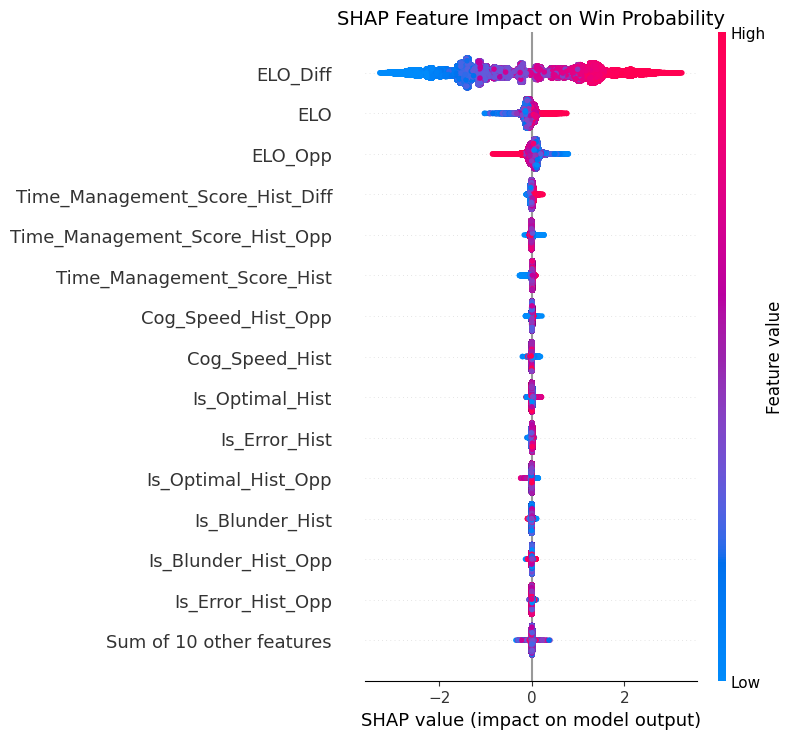

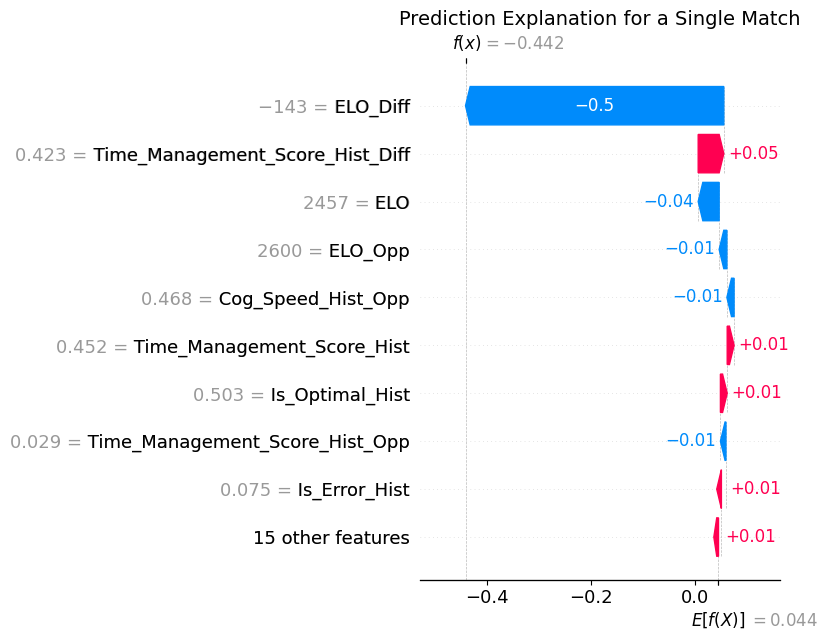

<Figure size 800x500 with 0 Axes>

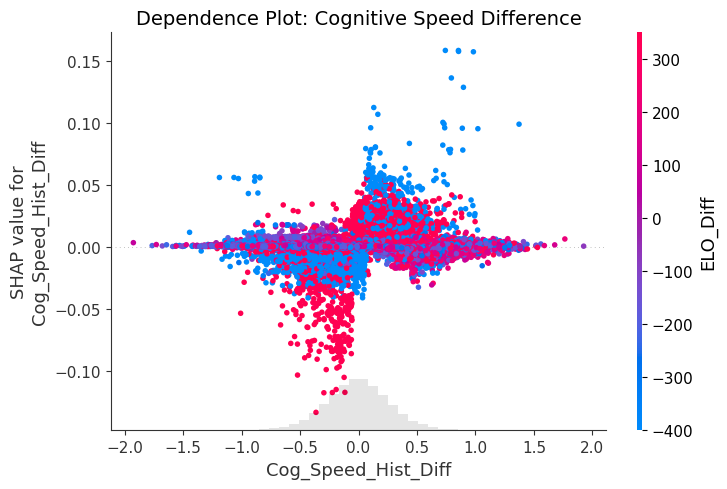

In [24]:
# 移除中文字体设置，保持纯英文
plt.style.use('default') 

# ======================
# SHAP Explainer (Using modern API for Explanation objects)
# ======================
# 注意：使用 shap.Explainer 可以直接生成带有基线值和特征名称的 Explanation 对象
explainer = shap.Explainer(clf)
shap_values_obj = explainer(X_test)

# 如果你的 lightGBM 版本导致 SHAP 输出具有第三个维度(二分类的两个类)，提取正类(Index 1)
if len(shap_values_obj.shape) == 3:
    shap_values_obj = shap_values_obj[:, :, 1]

# ======================
# Figure 1: SHAP Beeswarm Plot (The most important one for direction)
# ======================
plt.figure(figsize=(10, 6))
# 默认就是蜂群图，既有重要性排序，又有正负方向
shap.plots.beeswarm(shap_values_obj, max_display=15, show=False)
plt.title("SHAP Feature Impact on Win Probability", fontsize=14)
plt.tight_layout()
plt.show()

# ======================
# Figure 2: Single Match Waterfall Plot
# ======================
plt.figure(figsize=(9, 6))
# 观察测试集中第 0 个样本（第一局比赛）是如何被预测的
shap.plots.waterfall(shap_values_obj[0], max_display=10, show=False)
plt.title("Prediction Explanation for a Single Match", fontsize=14)
plt.tight_layout()
plt.show()

# ======================
# Figure 3: Dependence Plot (Trend for a specific feature)
# ======================
plt.figure(figsize=(8, 5))
# 这里以认知速度差为例，你可以换成你感兴趣的任何列
shap.plots.scatter(shap_values_obj[:, "Cog_Speed_Hist_Diff"], color=shap_values_obj[:, "ELO_Diff"], show=False)
plt.title("Dependence Plot: Cognitive Speed Difference", fontsize=14)
plt.tight_layout()
plt.show()